In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

from src.data_cleaning import load_data, clean_data
from src.visualizations import *

set_style()

In [2]:
df_raw = load_data('../data/diabetic_data.csv')
print(f"Raw shape: {df_raw.shape}")
df = clean_data(df_raw)
print(f"Cleaned shape: {df.shape}")
df.head()

Raw shape: (101766, 50)
Cleaned shape: (71518, 48)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


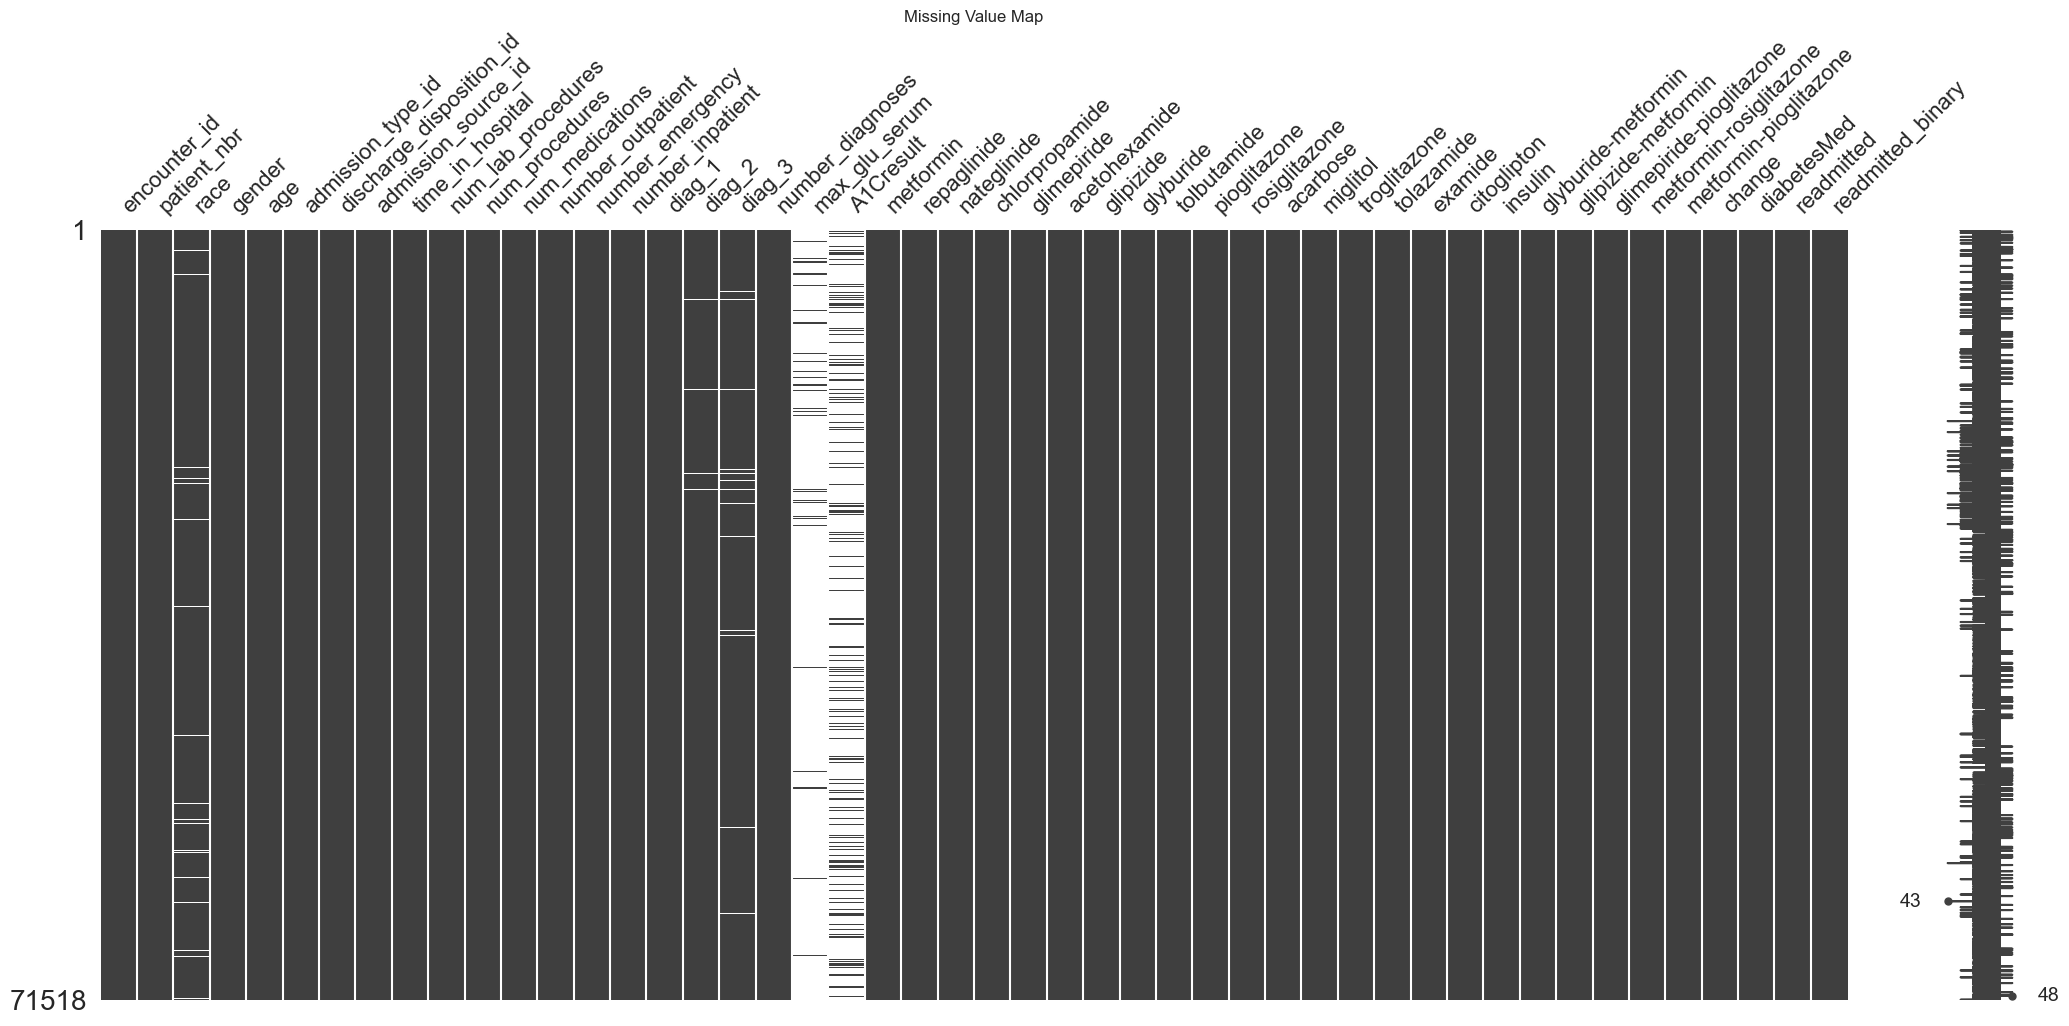

In [3]:
msno.matrix(df)
plt.title("Missing Value Map")
plt.savefig('../outputs/figures/missing_values.png')
plt.show()

In [4]:
print("Readmission Rate (within 30 days):", round(df['readmitted_binary'].mean() * 100, 2), "%")
print("\nAge group distribution:\n", df['age'].value_counts())
print("\nTop insulin usage:\n", df['insulin'].value_counts())

Readmission Rate (within 30 days): 8.8 %

Age group distribution:
 age
[70-80)     18210
[60-70)     15960
[50-60)     12466
[80-90)     11589
[40-50)      6878
[30-40)      2699
[90-100)     1900
[20-30)      1127
[10-20)       535
[0-10)        154
Name: count, dtype: int64

Top insulin usage:
 insulin
No        34921
Steady    22129
Down       7505
Up         6963
Name: count, dtype: int64


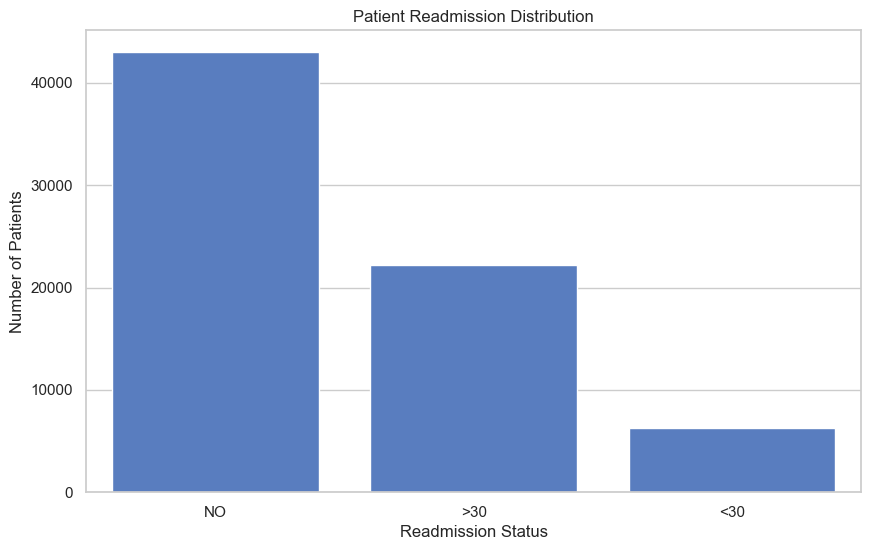

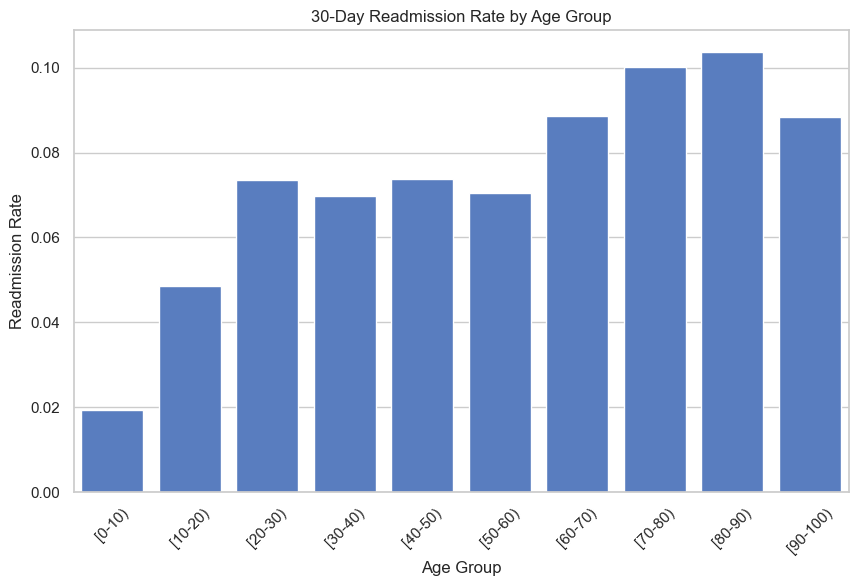

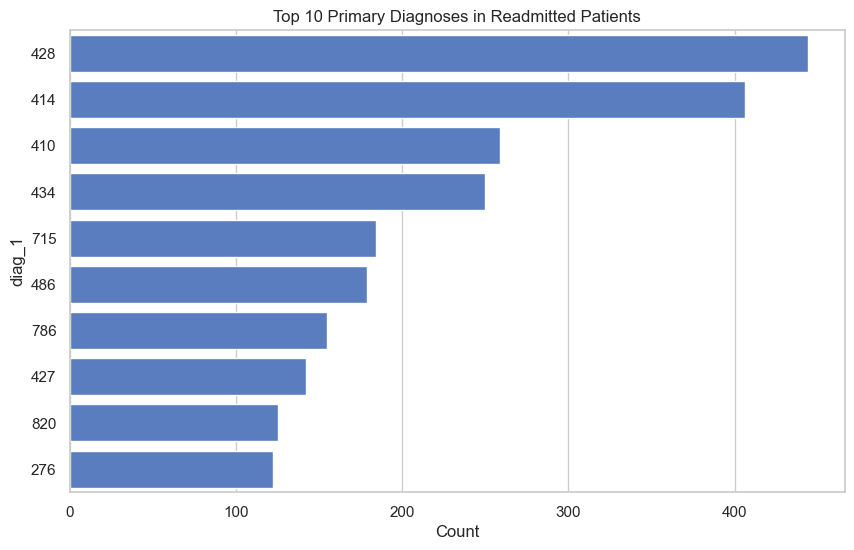

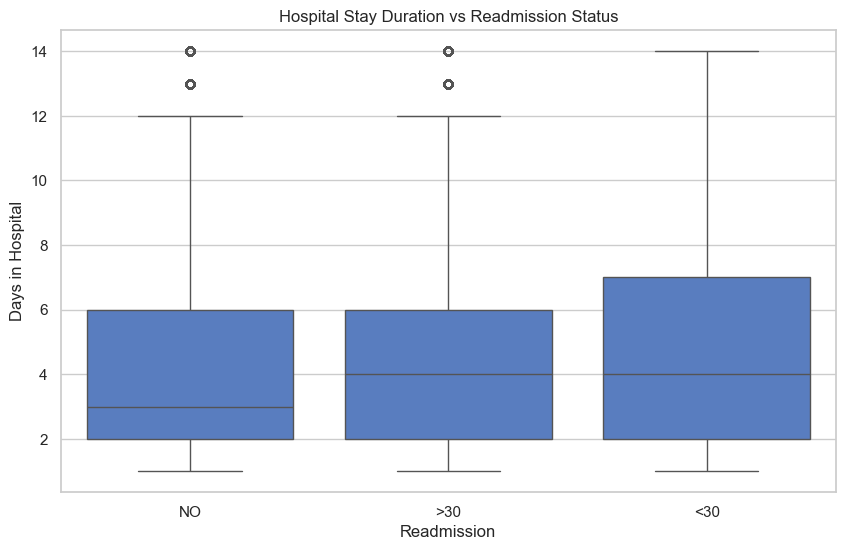

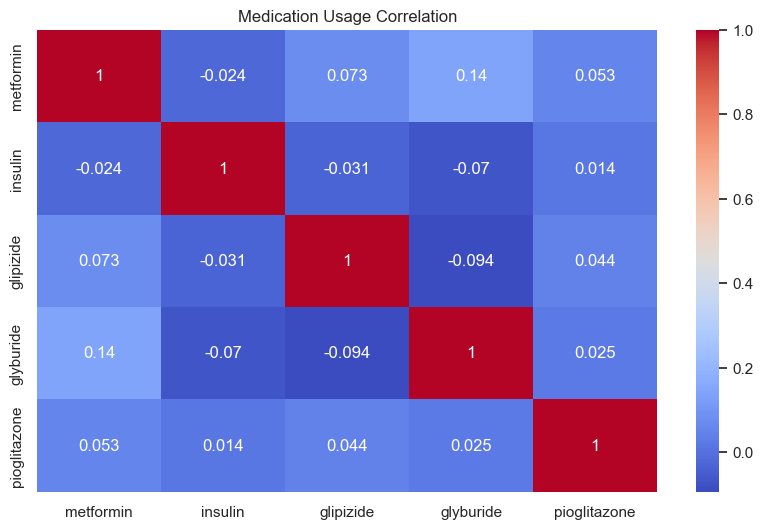

In [5]:
plot_readmission_distribution(df, save_path='../outputs/figures/readmission_dist.png')
plot_age_vs_readmission(df, save_path='../outputs/figures/age_readmission.png')
plot_top_diagnoses(df, save_path='../outputs/figures/top_diagnoses.png')
plot_time_in_hospital(df, save_path='../outputs/figures/hospital_stay.png')
plot_medications_heatmap(df, save_path='../outputs/figures/med_heatmap.png')